In [1]:
import os
import cv2
import torch
import random
import torchvision
import numpy as np
import pandas as pd
from torch import nn
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
from torch.optim import Adam
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision.transforms import v2
import segmentation_models_pytorch as smp
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import Dataset, DataLoader
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights, resnet18, efficientnet_b0, EfficientNet_B0_Weights

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class CrackSegmentationDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths
        
        self.transform = v2.Compose([
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True)
        ])
        
        self.images = []
        self.masks = []

        for img_path, mask_path in tqdm(paths):
            self.images.append(Image.open(img_path).convert("RGB"))
            self.masks.append(Image.open(mask_path).convert("1"))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image, mask = self.transform(self.images[idx], self.masks[idx])
        return image, mask

In [4]:
def list_examples(path: Path):
    # dataset structure:
    # images: $path/images/xxx
    # masks:  $path/masks/xxx
    # return tuples (image_path, mask_path)
    images_path = path / "images"
    masks_path = path / "masks"
    examples = []
    for img_file in images_path.iterdir():
        mask_file = masks_path / img_file.name
        if mask_file.exists():
            examples.append((img_file, mask_file))

    return examples

In [5]:
all_train_examples = list_examples(Path("train"))

# 80 / 20 split for training and validation sets
random.shuffle(all_train_examples)
split_idx = int(0.8 * len(all_train_examples))

train_examples = all_train_examples[:split_idx]
valid_examples = all_train_examples[split_idx:]

test_examples = list_examples(Path("test"))

# take a subset of dataset for quick testing
# rng = random.Random(42)
# train_examples = rng.sample(list_examples(Path("train")), 500)
# test_examples = rng.sample(list_examples(Path("test")), 80)

In [6]:
# train_dataset = CrackSegmentationDataset(train_examples)
# valid_dataset = CrackSegmentationDataset(valid_examples, augment=False)
test_ds = CrackSegmentationDataset(test_examples)

  0%|          | 0/1695 [00:00<?, ?it/s]

## Architecture - ResNet50 + GradCAM

In [7]:
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        assert kernel_size in (3, 7)
        padding = 3 if kernel_size == 7 else 1

        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)
        return self.sigmoid(x)


class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention()

    def forward(self, x):
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out

In [8]:
class ResNet50_CBAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torchvision.models.resnet50()
        self.model.fc = nn.Linear(2048, 1)

        checkpoint = torch.load('model_checkpoints/resnet50.pth')
        self.model.load_state_dict(checkpoint['model_state_dict'])
        
        for param in self.model.parameters():
            param.requires_grad = False


        # INSERT CBAM MODULES
        self.cbam2 = CBAM(512)   # output channels of layer2
        self.cbam3 = CBAM(1024)  # output channels of layer3
        self.cbam4 = CBAM(2048)  # output channels of layer4

    def forward(self, x):
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.relu(x)
        x = self.model.maxpool(x)

        x = self.model.layer1(x)
        # It is better not to insert cbam into early layers
        x = self.model.layer2(x)
        x = self.cbam2(x)

        x = self.model.layer3(x)
        x = self.cbam3(x)

        x = self.model.layer4(x)
        x = self.cbam4(x)

        x = self.model.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.model.fc(x)
        return x

In [9]:
model = ResNet50_CBAM().to(device)

for param in model.parameters():
    param.requires_grad = True

checkpoint = torch.load('model_checkpoints/resnet50_cbam.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval();

## GradCam

In [10]:
def grad_cam_segmentation(model, input_tensor, target_layers, thresh=0.6):
    """
    Grad-CAM segmentation with input upscaling, outputs rescaled to original size.
    """
    model.eval()
    batch_size = input_tensor.size(0)
    device = next(model.parameters()).device

    # Save original size
    orig_H, orig_W = input_tensor.shape[-2:]

    # Move to device and upscale the input
    input_tensor_up = F.interpolate(
        input_tensor.to(device), scale_factor=2, mode='bicubic', align_corners=False
    )

    # ---- 1) Forward pass ----
    with torch.no_grad():
        logits = model(input_tensor_up)
        probs = torch.sigmoid(logits).squeeze(1)
        preds = probs > 0.5

    # ---- 2) Prepare Grad-CAM ----
    cam = GradCAM(model=model, target_layers=target_layers)
    positive_idx = preds.nonzero(as_tuple=True)[0]

    # Prepare outputs (original size)
    final_masks = torch.zeros(batch_size, orig_H, orig_W, device=device)
    grayscale_out = [None] * batch_size
    overlay_out = [None] * batch_size

    if len(positive_idx) == 0:
        return final_masks, grayscale_out, overlay_out

    pos_inputs = input_tensor_up[positive_idx]
    targets = [BinaryClassifierOutputTarget(1)] * len(positive_idx)

    # ---- 3) Compute Grad-CAM heatmaps ----
    grayscale_cams = cam(input_tensor=pos_inputs, targets=targets)
    grayscale_cams = torch.from_numpy(grayscale_cams).to(device)

    # ---- 4) Threshold to get binary segmentation mask ----
    pos_masks = (grayscale_cams > thresh).float()

    # ---- 5) Rescale outputs to original input size ----
    for gcam, mask, idx in zip(grayscale_cams, pos_masks, positive_idx):
        # Resize mask back
        mask_resized = F.interpolate(mask.unsqueeze(0).unsqueeze(0), 
                                     size=(orig_H, orig_W), mode='bilinear', align_corners=False).squeeze()
        final_masks[idx] = mask_resized

        # Resize grayscale cam back
        gcam_resized = F.interpolate(gcam.unsqueeze(0).unsqueeze(0), 
                                     size=(orig_H, orig_W), mode='bilinear', align_corners=False).squeeze()
        grayscale_out[idx] = gcam_resized.detach().cpu().numpy()

        # Resize image back for overlay
        img_resized = F.interpolate(input_tensor_up[idx].unsqueeze(0), 
                                    size=(orig_H, orig_W), mode='bilinear', align_corners=False).squeeze()
        img_np = img_resized.permute(1, 2, 0).cpu().numpy()
        img_np = np.clip(img_np, 0, 1)

        overlay = show_cam_on_image(img_np, gcam_resized.cpu().numpy(), use_rgb=True)
        overlay_out[idx] = overlay

    return final_masks, grayscale_out, overlay_out

## Evaluation

In [11]:
def compute_metrics(preds: torch.Tensor, target: torch.Tensor, eps=1e-8):
    """Compute IoU, precision, recall, F1 for binary masks."""
    preds = preds.int()
    target = target.int()

    intersection = (preds & target).sum(dim=(1, 2, 3))
    union = (preds | target).sum(dim=(1, 2, 3))
    iou = (intersection + eps) / (union + eps)

    true_pos = intersection
    false_pos = ((preds == 1) & (target == 0)).sum(dim=(1, 2, 3))
    false_neg = ((preds == 0) & (target == 1)).sum(dim=(1, 2, 3))

    precision = (true_pos + eps) / (true_pos + false_pos + eps)
    recall = (true_pos + eps) / (true_pos + false_neg + eps)
    f1 = 2 * (precision * recall) / (precision + recall + eps)

    return iou.mean().item(), precision.mean().item(), recall.mean().item(), f1.mean().item()

In [12]:
def inference(model, images):
    # images: (B, C, H, W)
    return grad_cam_segmentation(model, images, [model.model.layer4], thresh=0.6)

def evaluate_on_dataset(test_dataset):
    total_iou = 0.0
    total_prec = 0.0
    total_rec = 0.0
    total_f1 = 0.0

    for i in tqdm(range(len(test_dataset)), desc="evaluation..."):
        image, mask = test_dataset[i]
        image = image.unsqueeze(0).to(device)      # (1, C, H, W)
        true_mask = mask[None, None].to(device)    # (1, 1, H, W)

        pred_mask, _, _ = inference(model, image)
        pred_mask = pred_mask.to(device)

        # ---- use your helper ----
        iou, prec, rec, f1 = compute_metrics(pred_mask, true_mask)

        total_iou  += iou
        total_prec += prec
        total_rec  += rec
        total_f1   += f1

    avg_iou = total_iou / len(test_dataset)
    avg_prec = total_prec / len(test_dataset)
    avg_rec  = total_rec / len(test_dataset)
    avg_f1   = total_f1 / len(test_dataset)

    print(f"Average IoU:  {avg_iou:.4f}")
    print(f"Precision:    {avg_prec:.4f}")
    print(f"Recall:       {avg_rec:.4f}")
    print(f"F1-score:     {avg_f1:.4f}")

evaluation...:   0%|          | 0/1695 [00:00<?, ?it/s]

Average IoU:  0.4262
Precision:    0.7797
Recall:       0.5401
F1-score:     0.4513


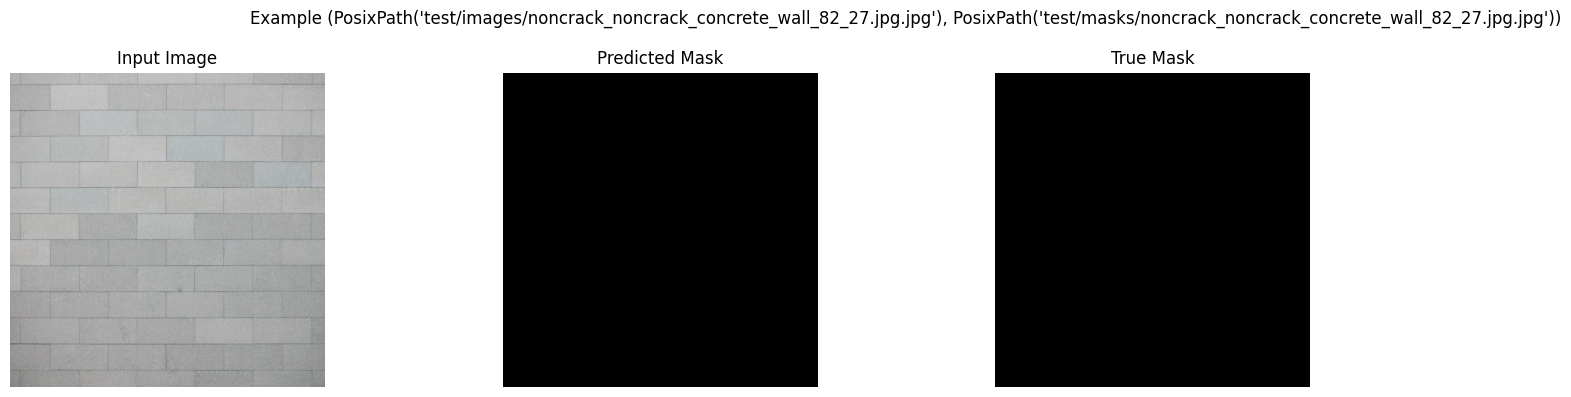

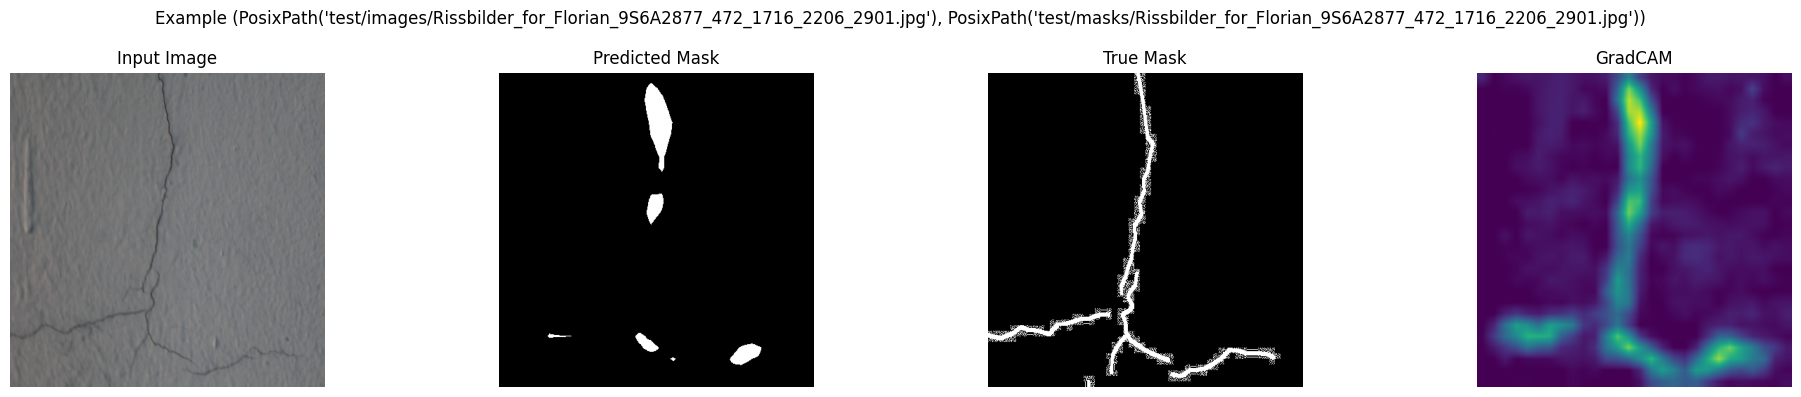

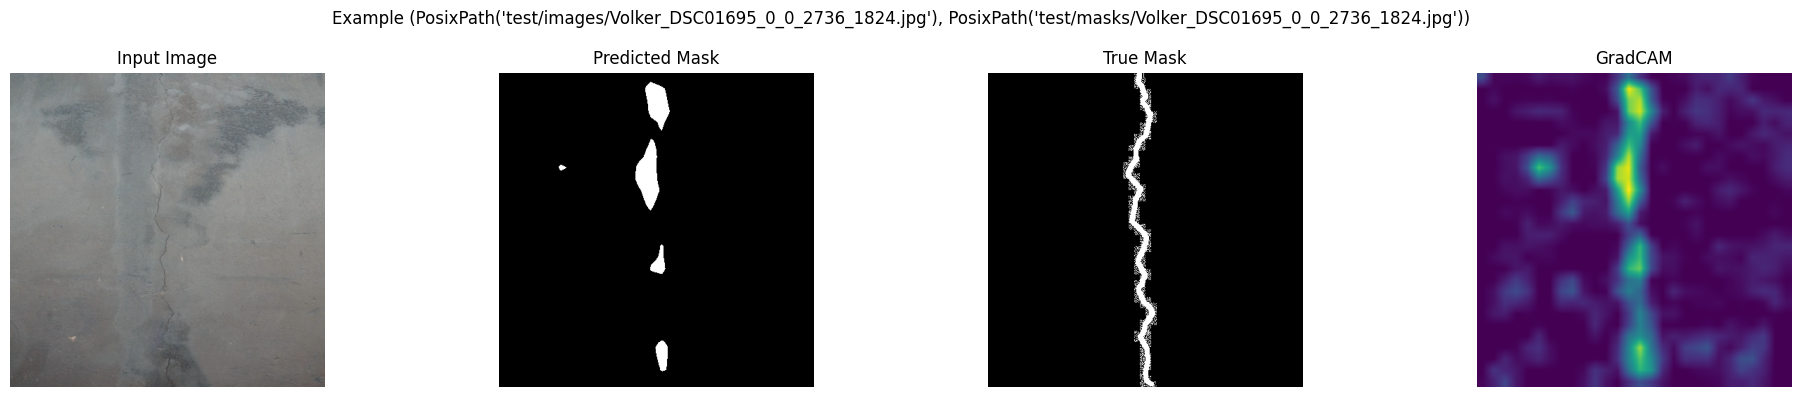

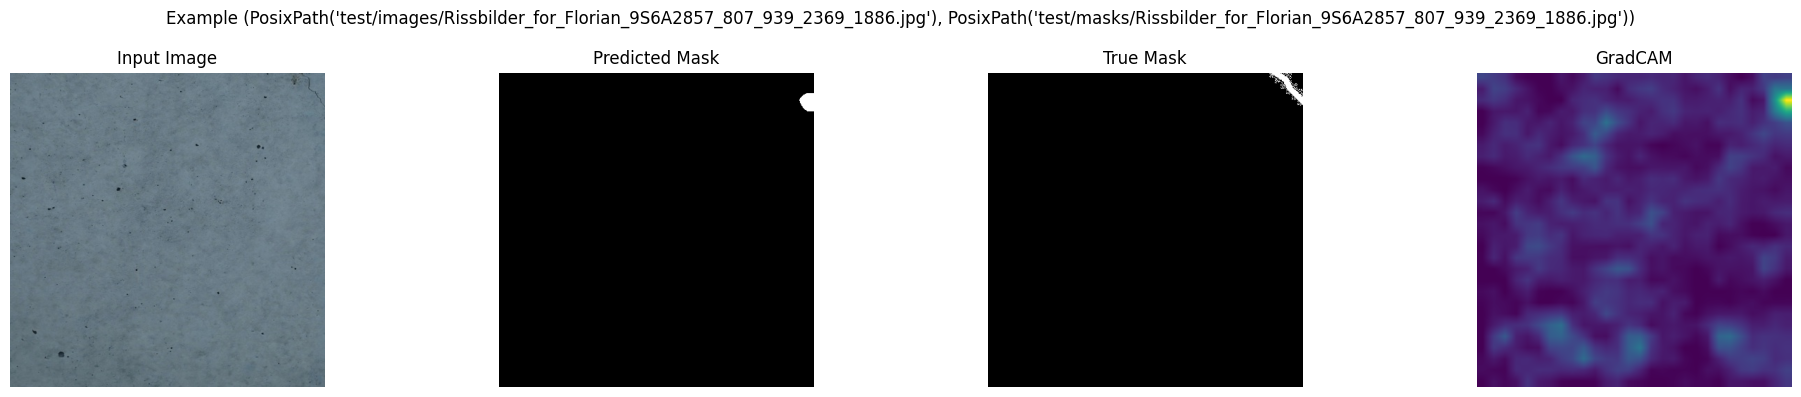

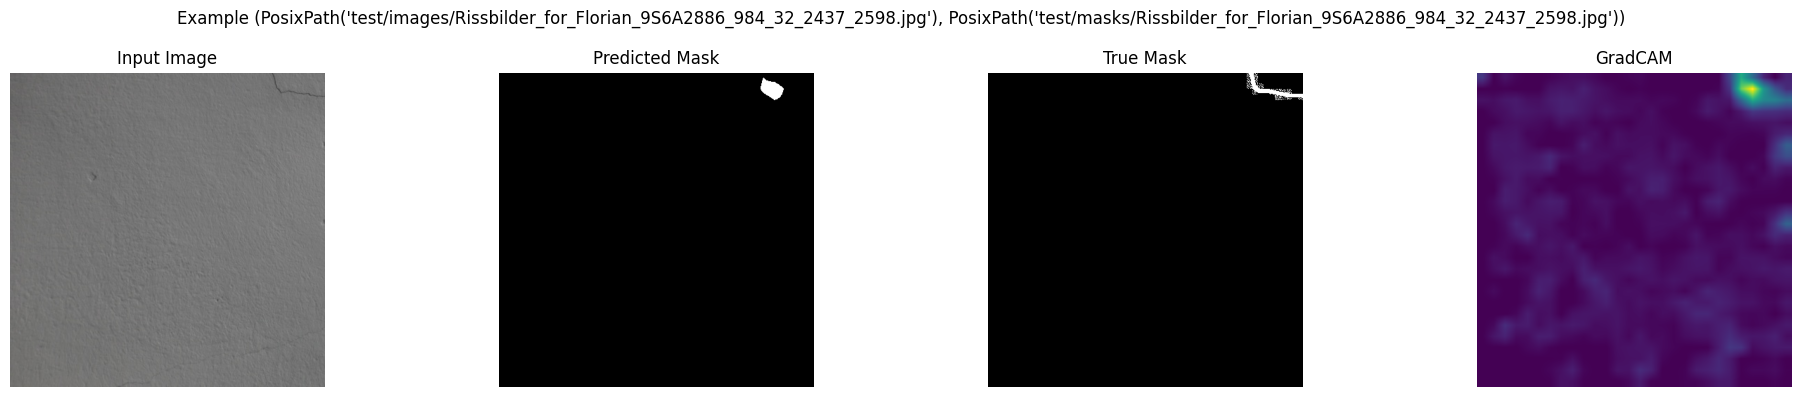

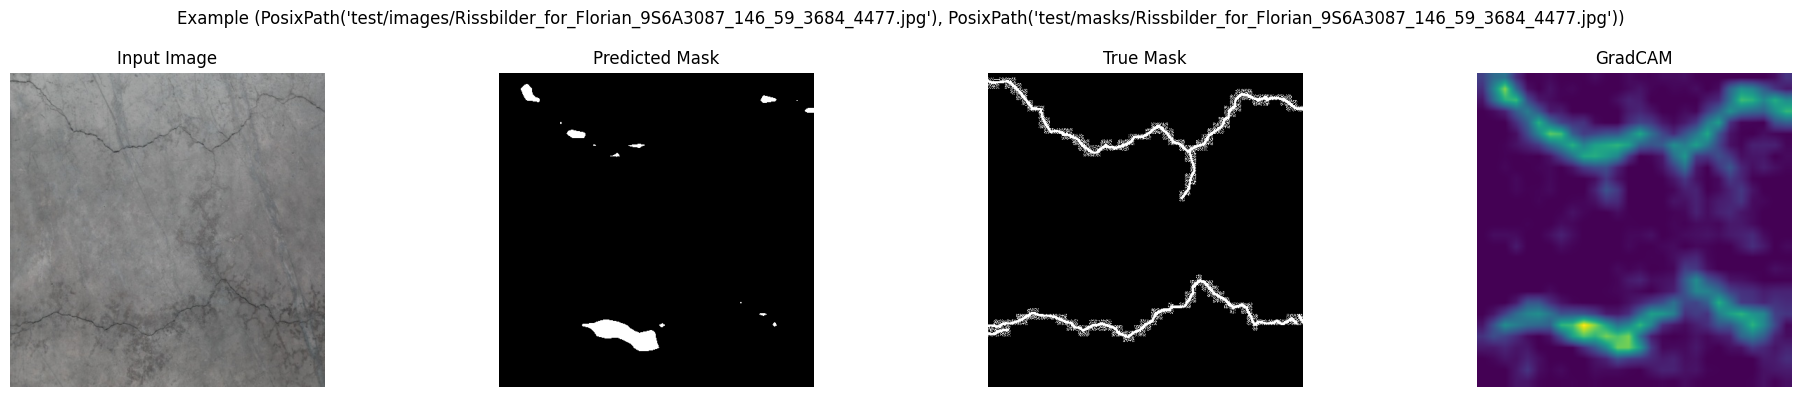

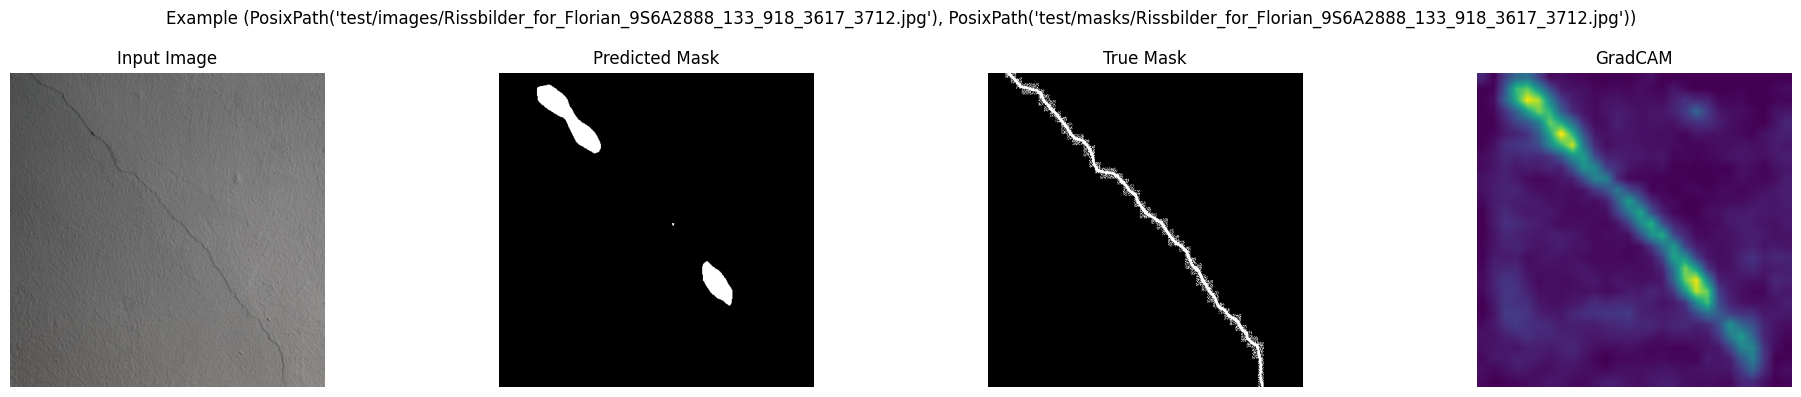

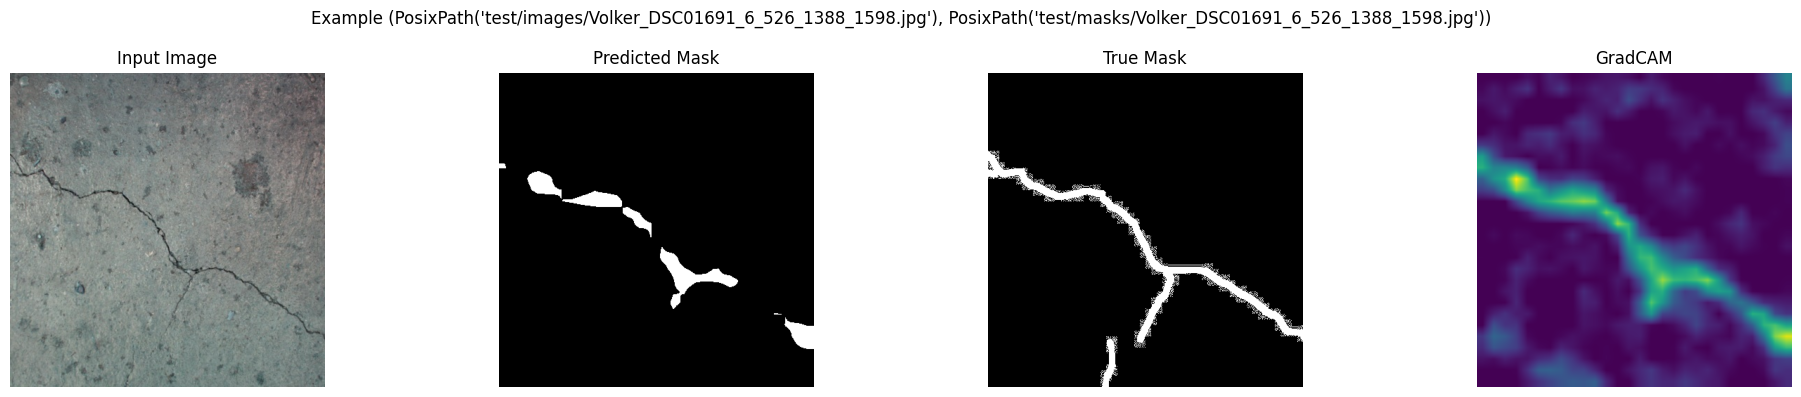

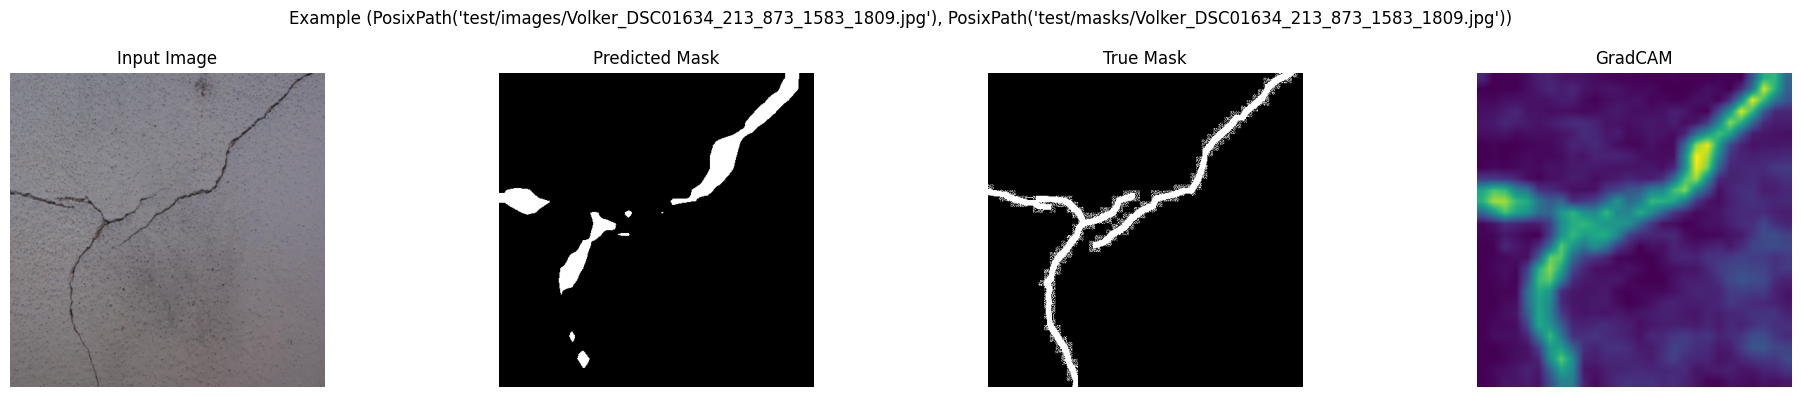

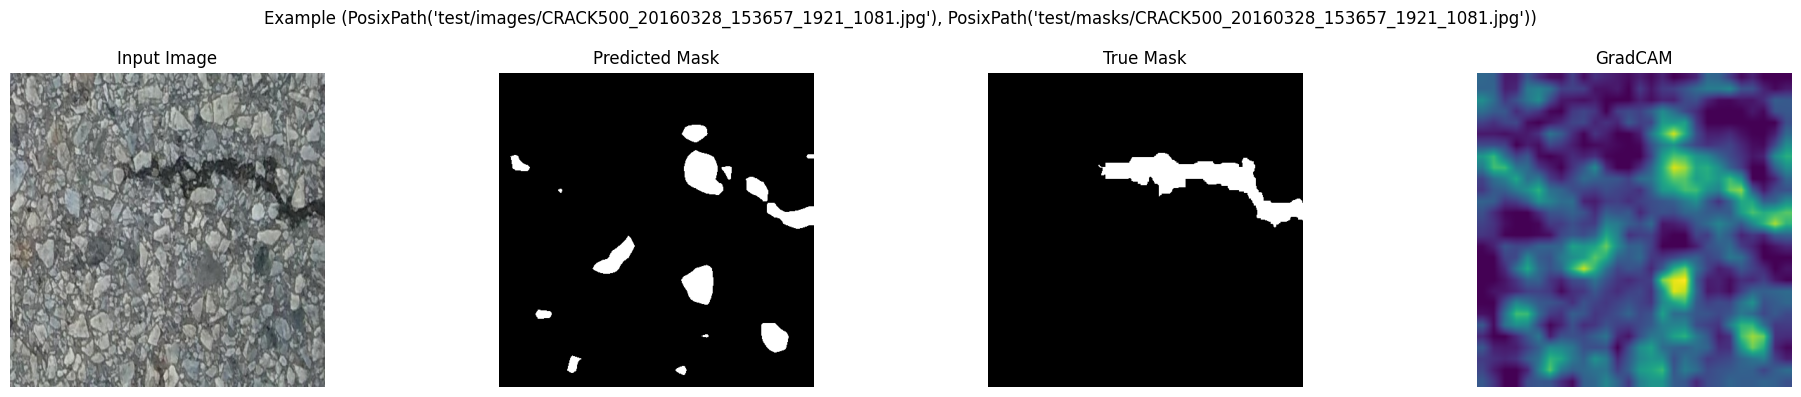

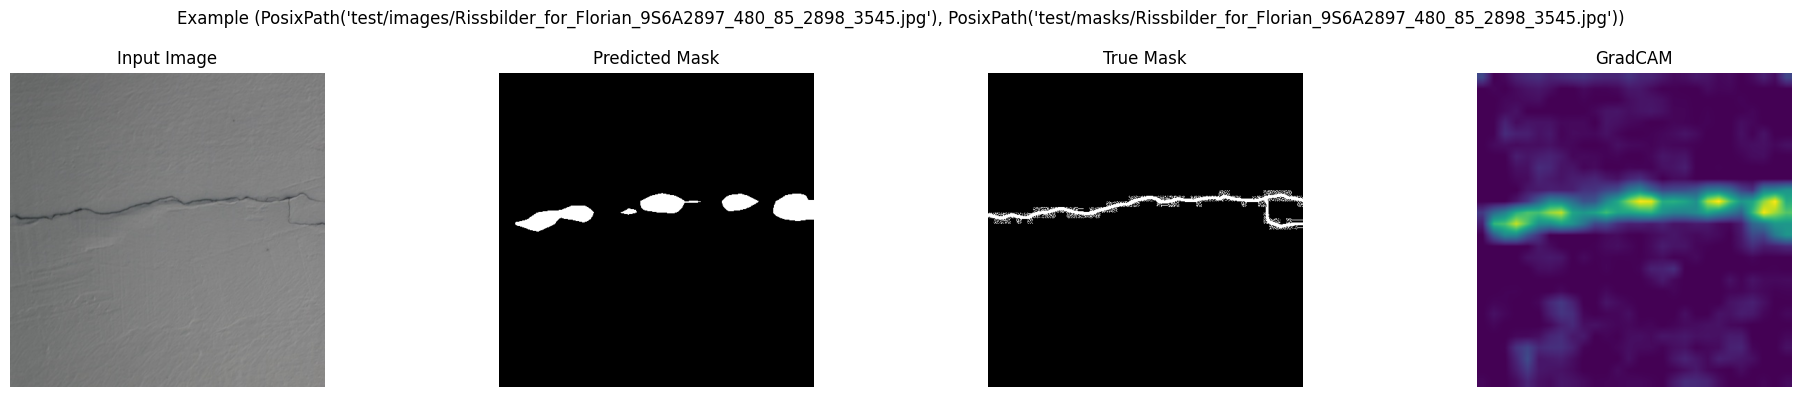

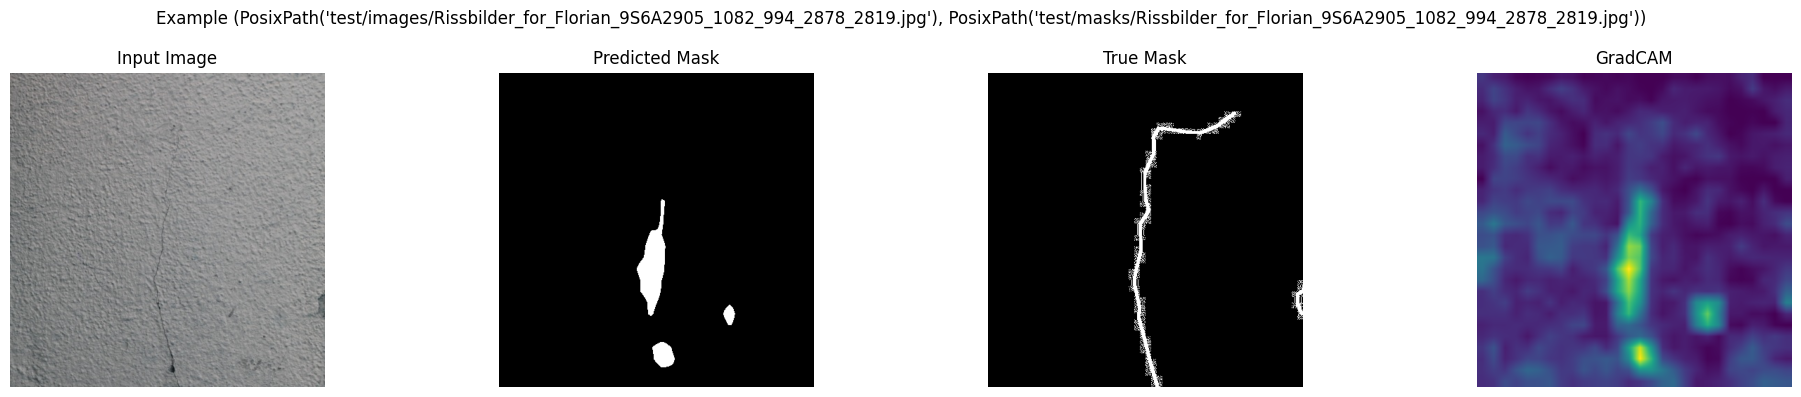

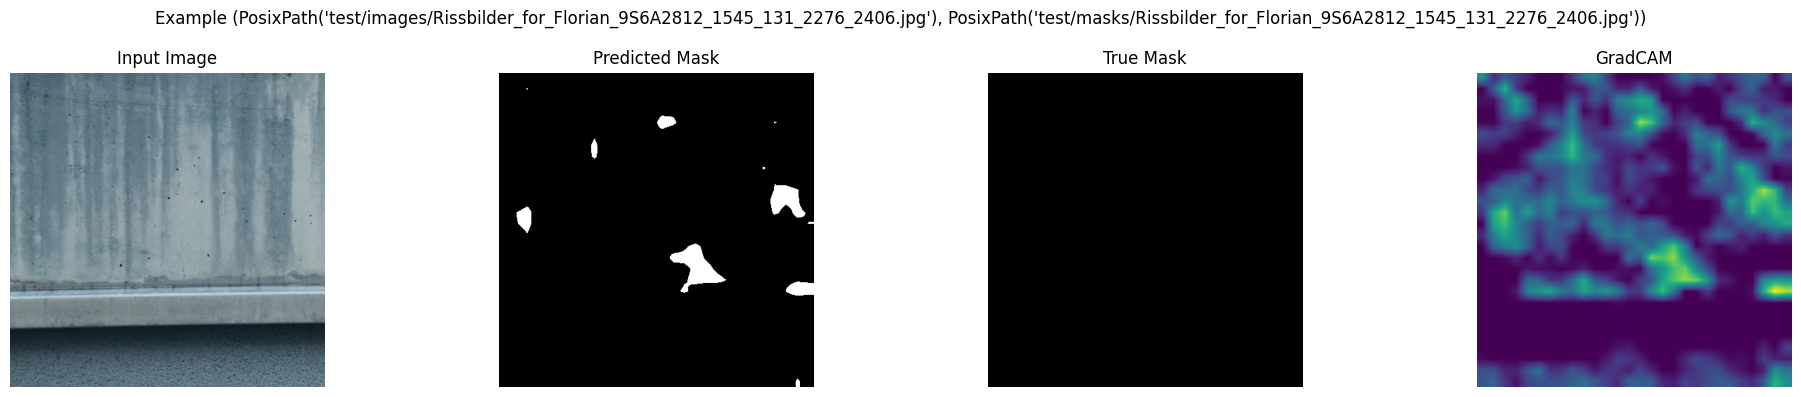

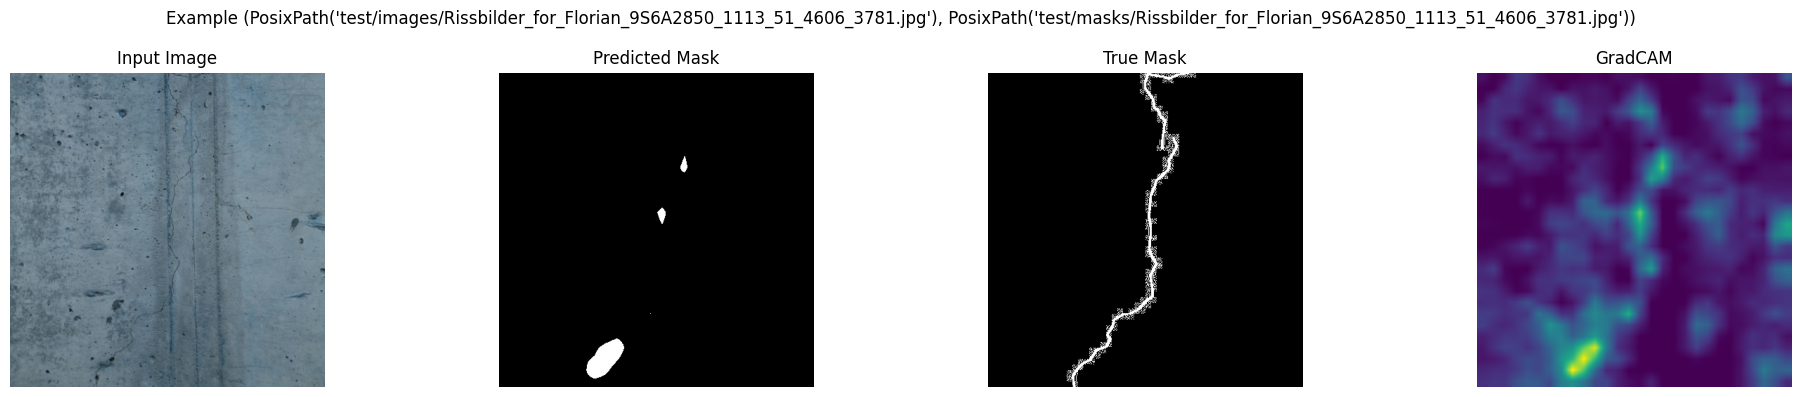

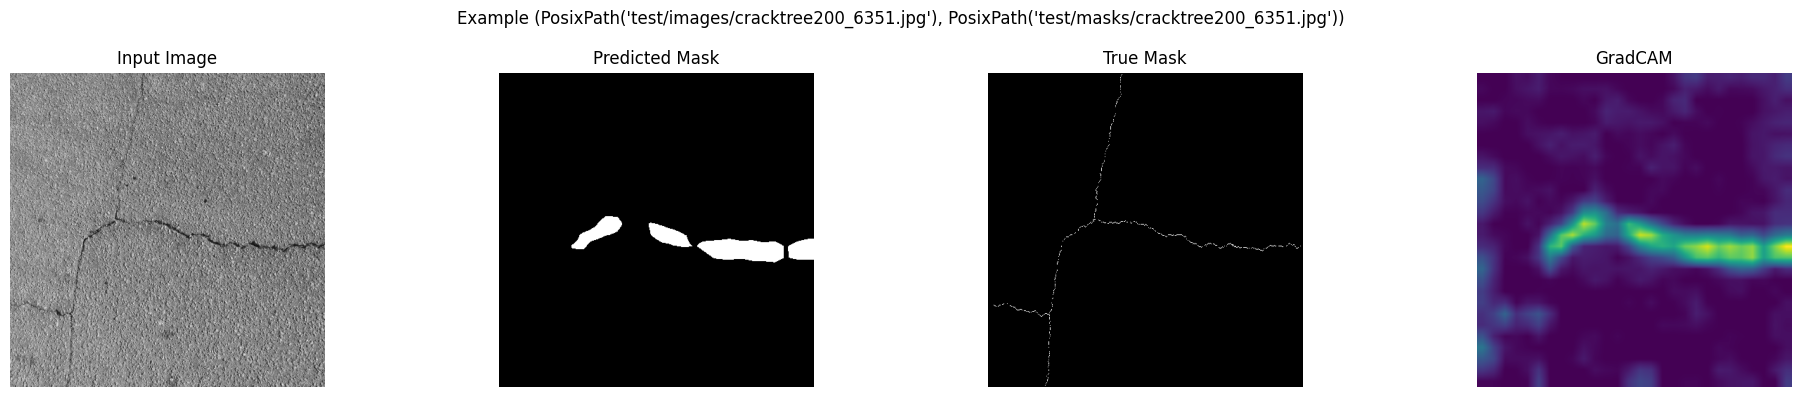

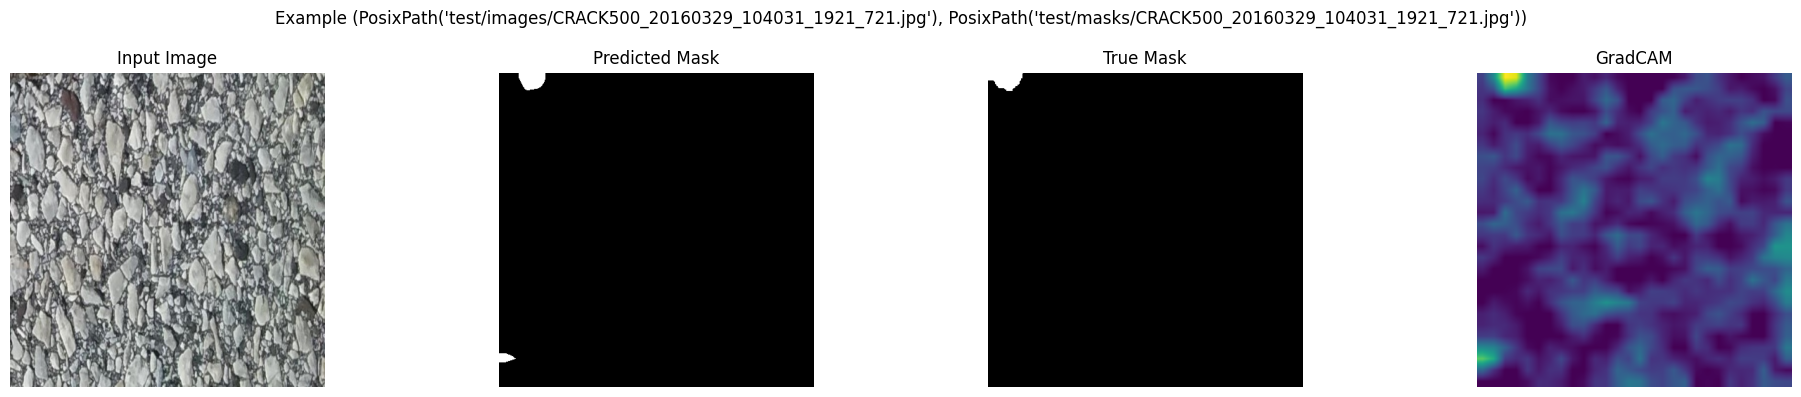

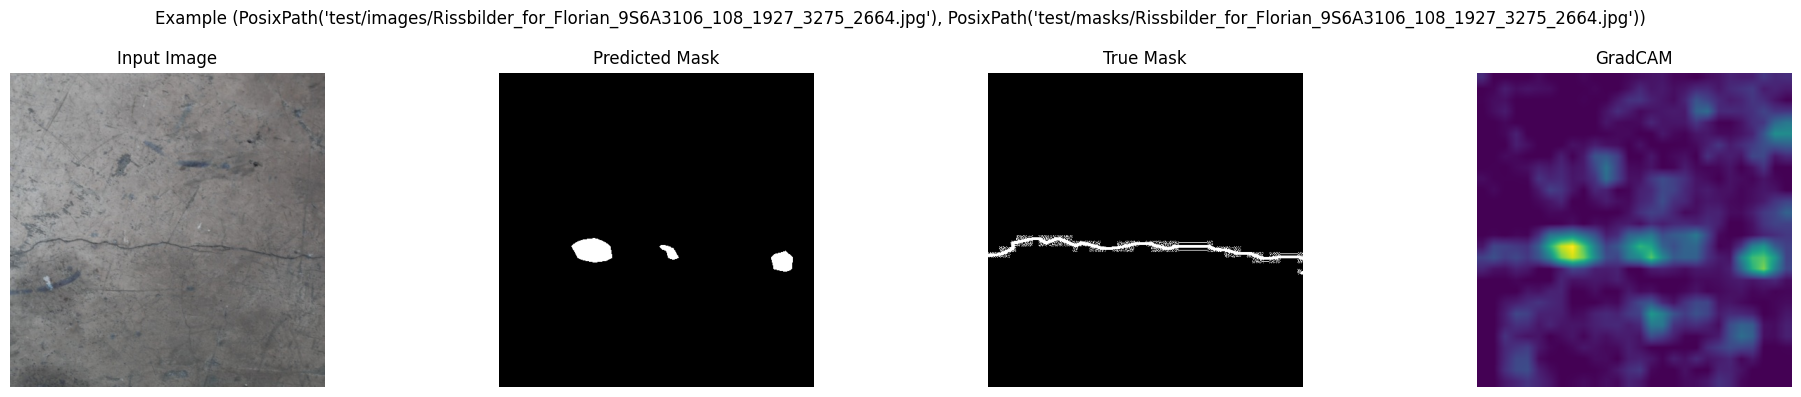

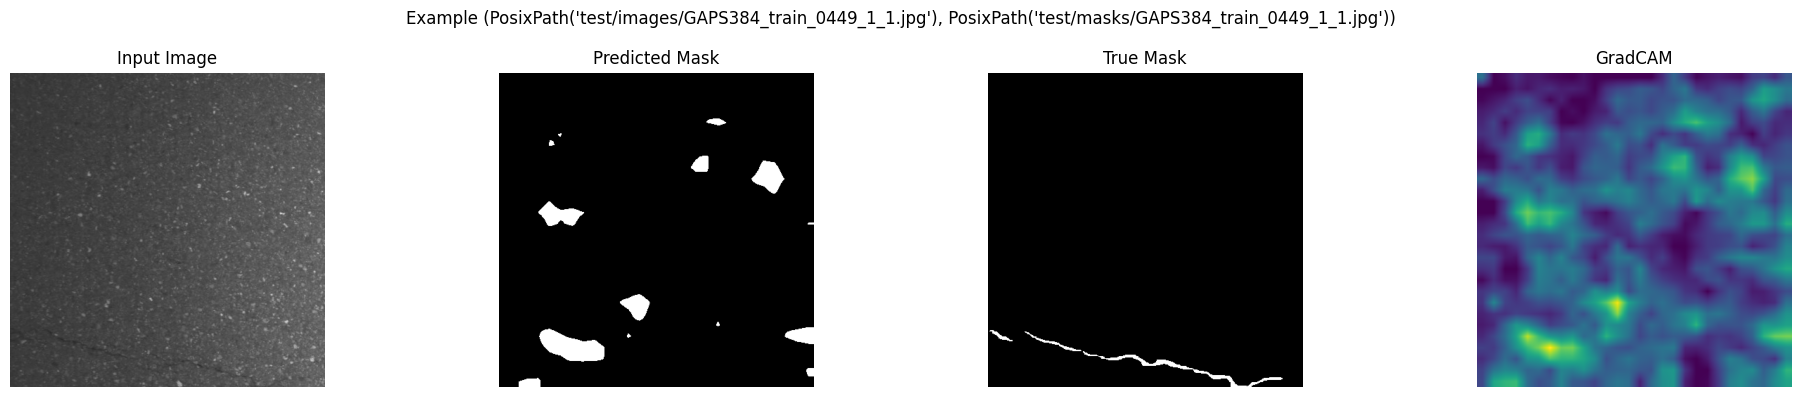

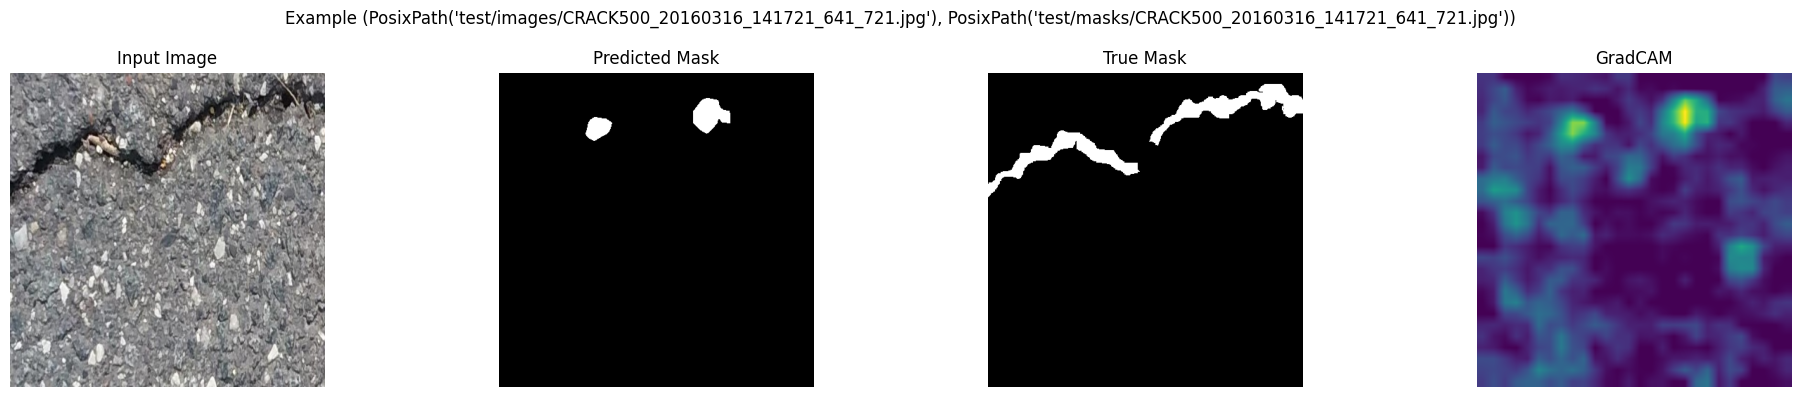

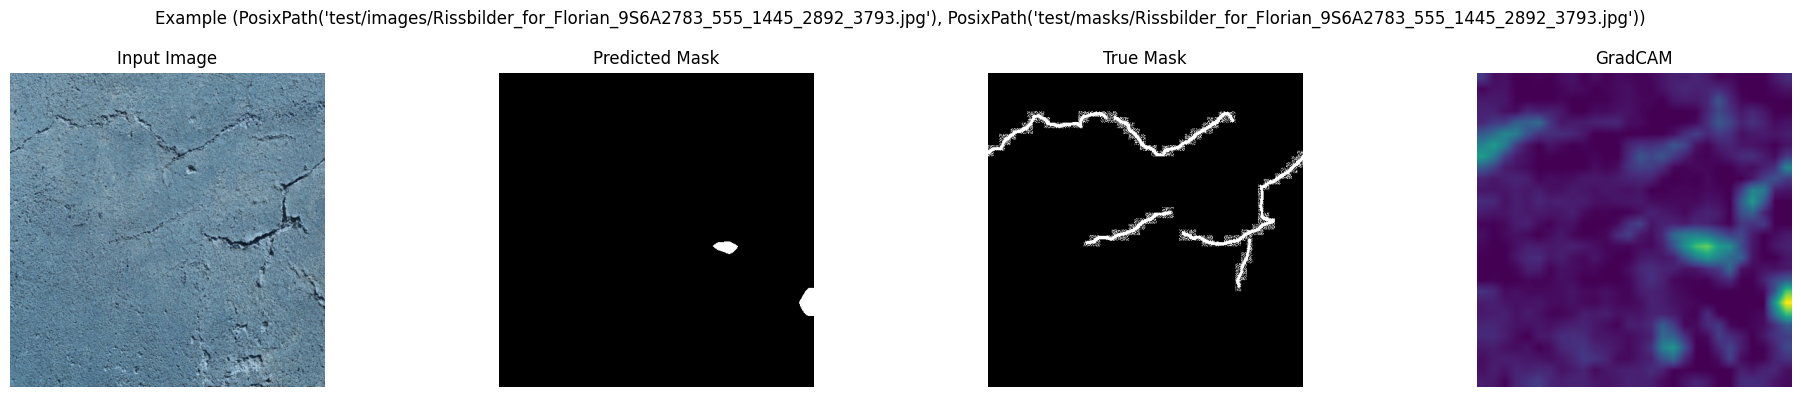

In [13]:
model.eval()
# test_examples = list_examples(Path("test"))
# test_dataset = CrackSegmentationDataset(test_examples, augment=False)

evaluate_on_dataset(test_ds)

# visualize
for i in range(20):
    image, mask = test_ds[i]
    image = image.unsqueeze(0).to(device)
    pred_mask, gradcam_overlay, raw_cam  = inference(model, image)
    pred_mask = (pred_mask > 0.5).float()
    
    gradcam_overlay = gradcam_overlay[0]
    raw_cam = raw_cam[0]

    # ---- Plotting ----
    plt.figure(figsize=(20, 4))
    plt.suptitle(f"Example {test_ds.paths[i]}", fontsize=12)

    # 1) Input
    plt.subplot(1, 4, 1)
    plt.title("Input Image")
    plt.imshow(image.squeeze(0).permute(1, 2, 0).cpu().numpy())
    plt.axis("off")

    # 2) Predicted Mask
    plt.subplot(1, 4, 2)
    plt.title("Predicted Mask")
    plt.imshow(pred_mask.squeeze().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    plt.axis("off")

    # 3) True Mask
    plt.subplot(1, 4, 3)
    plt.title("True Mask")
    plt.imshow(mask.squeeze().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    plt.axis("off")

    if gradcam_overlay is not None:
        # 4) Grad-CAM
        plt.subplot(1, 4, 4)
        plt.title("GradCAM")
        plt.imshow(gradcam_overlay)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In some images I am not using all of the Grad-CAM mask that overlaps with the true mask, but at the same time I am avoiding including a lot of noise from images where the network is not sure where exactly the cracks are

In [14]:
def mask2rle(img):
    '''
    img: numpy array, 1 -> mask, 0 -> background
    Returns run length as string formated
    '''
    pixels= img.T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs)

In [15]:
rows = []
batch_size = 8

for i in tqdm(range(0, len(test_ds), batch_size)):
    batch_indices = list(range(i, min(i + batch_size, len(test_ds))))
    
    images = torch.stack([test_ds[idx][0] for idx in batch_indices]).to(device)
    filenames = [Path(test_ds.paths[idx][0]).name for idx in batch_indices]
    
    pred_masks = (inference(model, images)[0]).cpu().numpy()  # (B,H,W)
    
    for filename, pred_mask in zip(filenames, pred_masks):
        cracks = mask2rle(pred_mask > 0.5)
        rows.append({"file": filename, "crack": cracks})

df = pd.DataFrame(rows)
df.to_csv("predicted_cracks.csv", index=False)


  0%|          | 0/212 [00:00<?, ?it/s]

In [16]:
df = pd.DataFrame(rows)
df.to_csv("predicted_cracks.csv", index=False)

In [17]:
df[df["file"] == "noncrack_noncrack_concrete_wall_82_27.jpg.jpg"]

,file,crack
0,noncrack_noncrack_concrete_wall_82_27.jpg.jpg,


                                                file  \
0      noncrack_noncrack_concrete_wall_82_27.jpg.jpg   
1  Rissbilder_for_Florian_9S6A2877_472_1716_2206_...   
2                  Volker_DSC01695_0_0_2736_1824.jpg   
3  Rissbilder_for_Florian_9S6A2857_807_939_2369_1...   
4  Rissbilder_for_Florian_9S6A2886_984_32_2437_25...   

                                               crack  
0                                                NaN  
1  31288 1 31735 3 32182 5 32629 6 33078 5 33526 ...  
2  38216 2 38662 6 39109 8 39557 8 40005 8 40454 ...  
3  191336 2 191782 7 192229 10 192676 13 193123 1...  
4  166677 5 167121 11 167565 16 168010 20 168457 ...  


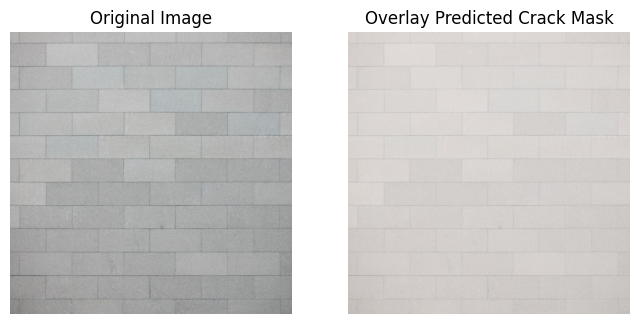

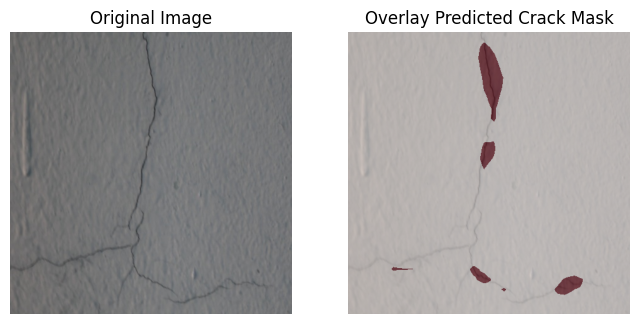

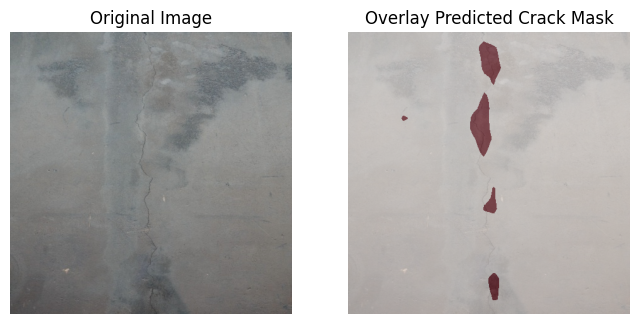

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# --- Load CSV ---
df = pd.read_csv("predicted_cracks.csv")
print(df.head())

# --- Helper: decode RLE into mask ---
def rle_decode(rle, shape):
    """
    rle: string of start length pairs, e.g. "230 8 678 9"
    shape: (H, W)
    """
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    if pd.isna(rle) or rle.strip() == "":
        return mask.reshape(shape)
    
    parts = list(map(int, rle.strip().split()))
    for i in range(0, len(parts), 2):
        start = parts[i]
        length = parts[i+1]
        mask[start:start+length] = 1
    return mask.reshape(shape)

# --- Pick a few examples to visualize ---
example_rows = df.sample(3)  # pick 3 random rows
selected_files = [p[0].name for p in test_ds.paths[:3]]
example_rows = df[df["file"].isin(selected_files)]

for _, row in example_rows.iterrows():
    img_path = Path("test/images") / row["file"]  # adjust path if needed
    image = np.array(Image.open(img_path).convert("RGB")) / 255.0  # normalize for visualization
    H, W, _ = image.shape
    
    mask = rle_decode(row["crack"], (H, W))
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(image)
    plt.imshow(mask.T, alpha=0.5, cmap="Reds")
    plt.title("Overlay Predicted Crack Mask")
    plt.axis("off")
    
    plt.show()
